# SupplyShield AI — Supply Chain Intelligence EDA

**Member 2 | Data Analytics, Database & AI/ML**

This notebook performs production-oriented exploratory data analysis on the trusted unified dataset generated by Member 1. The analysis focuses on data quality, source coverage, market signals, price behavior, product intelligence, anomaly discovery, and downstream feature engineering readiness.

In [1]:
# ============================================================
# SUPPLYSHIELD AI
# MEMBER 2 — SUPPLY CHAIN INTELLIGENCE
# ENVIRONMENT & DEPENDENCIES
# ============================================================

from __future__ import annotations

import sys
import json
import logging
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Project paths
# ------------------------------------------------------------

PROJECT_ROOT = Path.cwd().resolve()

# Notebook is expected inside:
# SupplyShield-AI/member2/notebooks/
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent.parent

# Fallback protection if notebook is launched elsewhere
if not (PROJECT_ROOT / "member1").exists():
    possible_root = Path.cwd()

    for parent in [Path.cwd(), *Path.cwd().parents]:
        if (parent / "member1").exists():
            PROJECT_ROOT = parent
            break

SRC_PATH = PROJECT_ROOT / "member2" / "src"

OUTPUT_ROOT = PROJECT_ROOT / "member2" / "outputs"
EDA_OUTPUT = OUTPUT_ROOT / "eda"
FIGURE_OUTPUT = OUTPUT_ROOT / "figures"

EDA_OUTPUT.mkdir(parents=True, exist_ok=True)
FIGURE_OUTPUT.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Import Member 2 production loader
# ------------------------------------------------------------

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from preprocessing.data_loader import prepare_dataset

# ------------------------------------------------------------
# Display configuration
# ------------------------------------------------------------

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ------------------------------------------------------------
# Logging
# ------------------------------------------------------------

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
)

print("=" * 80)
print("SUPPLYSHIELD AI — MEMBER 2")
print("SUPPLY CHAIN INTELLIGENCE EDA")
print("=" * 80)

print(f"\nPython version : {sys.version.split()[0]}")
print(f"Project root  : {PROJECT_ROOT}")
print(f"Source path   : {SRC_PATH}")
print(f"EDA output    : {EDA_OUTPUT}")
print(f"Figure output : {FIGURE_OUTPUT}")

SUPPLYSHIELD AI — MEMBER 2
SUPPLY CHAIN INTELLIGENCE EDA

Python version : 3.13.1
Project root  : C:\Users\Pradeep Bhat\Documents\Hackathons\SupplyShield-AI
Source path   : C:\Users\Pradeep Bhat\Documents\Hackathons\SupplyShield-AI\member2\src
EDA output    : C:\Users\Pradeep Bhat\Documents\Hackathons\SupplyShield-AI\member2\outputs\eda
Figure output : C:\Users\Pradeep Bhat\Documents\Hackathons\SupplyShield-AI\member2\outputs\figures


## 1. Load and Validate the Trusted Dataset

In [2]:
# ============================================================
# LOAD TRUSTED UNIFIED DATASET
# ============================================================

df, quality_report, metadata = prepare_dataset()

# Defensive copy for notebook analysis
df = df.copy()

print("=" * 80)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 80)

print(f"\nOriginal records       : {metadata['original_rows']:,}")
print(f"Analysis-ready records: {metadata['final_rows']:,}")
print(f"Duplicates removed    : {metadata['duplicates_removed']:,}")
print(f"Number of columns     : {metadata['column_count']:,}")
print(f"DataFrame shape       : {df.shape}")

print("\nSource distribution:")
for source, count in metadata["source_distribution"].items():
    print(f"  {str(source):<25} {count:,}")

print("\nDataset memory usage:")
memory_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"  {memory_mb:.4f} MB")

2026-08-20 22:29:57,154 | INFO | Loading unified dataset: C:\Users\Pradeep Bhat\Documents\Hackathons\SupplyShield-AI\member1\supply-webshield\data\processed\unified_supply_data.json
2026-08-20 22:29:57,162 | INFO | Loaded 303 records (303 valid dictionary records).
2026-08-20 22:29:57,170 | INFO | Created DataFrame with shape: (303, 15)
2026-08-20 22:29:57,219 | INFO | Exact duplicate rows removed: 0
2026-08-20 22:29:57,236 | INFO | Final dataset shape: (303, 15)


DATASET LOADED SUCCESSFULLY

Original records       : 303
Analysis-ready records: 303
Duplicates removed    : 0
Number of columns     : 15
DataFrame shape       : (303, 15)

Source distribution:
  TradeIndia                247
  Meesho                    40
  DeoDap                    16

Dataset memory usage:
  0.2409 MB


In [3]:
# ============================================================
# DATASET INTEGRITY & STRUCTURAL VALIDATION
# ============================================================

required_columns = {
    "source",
    "title",
    "company",
    "supplier",
    "product",
    "event",
    "location",
    "price",
    "currency",
    "availability",
    "rating",
    "review",
    "date",
    "url",
    "timestamp",
}

actual_columns = set(df.columns)

missing_required_columns = sorted(
    required_columns - actual_columns
)

unexpected_columns = sorted(
    actual_columns - required_columns
)

integrity_results = {
    "dataset_non_empty": len(df) > 0,
    "required_columns_present": len(missing_required_columns) == 0,
    "duplicate_rows": int(df.duplicated().sum()),
    "row_count": int(len(df)),
    "column_count": int(len(df.columns)),
    "missing_required_columns": missing_required_columns,
    "unexpected_columns": unexpected_columns,
}

print("=" * 80)
print("DATASET INTEGRITY CHECK")
print("=" * 80)

print(f"\nDataset non-empty       : {integrity_results['dataset_non_empty']}")
print(
    f"Required columns valid  : "
    f"{integrity_results['required_columns_present']}"
)
print(f"Duplicate rows          : {integrity_results['duplicate_rows']}")
print(f"Rows                    : {integrity_results['row_count']:,}")
print(f"Columns                 : {integrity_results['column_count']:,}")

if missing_required_columns:
    print("\nMissing required columns:")
    print(missing_required_columns)
else:
    print("\nAll expected business fields are present.")

if unexpected_columns:
    print("\nAdditional fields detected:")
    print(unexpected_columns)

DATASET INTEGRITY CHECK

Dataset non-empty       : True
Required columns valid  : True
Duplicate rows          : 0
Rows                    : 303
Columns                 : 15

All expected business fields are present.


In [4]:
# ============================================================
# COMPREHENSIVE SCHEMA PROFILE
# ============================================================

schema_profile = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "non_null_count": df.notna().sum().values,
    "missing_count": df.isna().sum().values,
    "unique_count": df.nunique(dropna=True).values,
})

schema_profile["missing_percentage"] = (
    schema_profile["missing_count"]
    / len(df)
    * 100
).round(2)

schema_profile["uniqueness_percentage"] = (
    schema_profile["unique_count"]
    / len(df)
    * 100
).round(2)

schema_profile = schema_profile.sort_values(
    by=["missing_percentage", "column"],
    ascending=[False, True],
).reset_index(drop=True)

display(schema_profile)

schema_profile.to_csv(
    EDA_OUTPUT / "schema_profile.csv",
    index=False,
)

print(
    f"\nSchema profile exported to: "
    f"{EDA_OUTPUT / 'schema_profile.csv'}"
)

,column,dtype,non_null_count,missing_count,unique_count,missing_percentage,uniqueness_percentage
0,date,"datetime64[ns, UTC]",0,303,0,100.000,0.000
1,rating,float64,45,258,26,85.150,8.580
2,price,float64,255,48,206,15.840,67.990
3,availability,object,303,0,2,0.000,0.660
4,company,object,303,0,273,0.000,90.100
5,currency,object,303,0,3,0.000,0.990
6,event,object,303,0,1,0.000,0.330
7,location,object,303,0,1,0.000,0.330
8,product,object,303,0,288,0.000,95.050
9,review,object,303,0,42,0.000,13.860



Schema profile exported to: C:\Users\Pradeep Bhat\Documents\Hackathons\SupplyShield-AI\member2\outputs\eda\schema_profile.csv


## 2. Data Quality and Missingness

In [5]:
# ============================================================
# MISSING DATA ANALYSIS
# ============================================================

missing_analysis = (
    df.isna()
    .sum()
    .rename("missing_count")
    .to_frame()
)

missing_analysis["total_records"] = len(df)

missing_analysis["missing_percentage"] = (
    missing_analysis["missing_count"]
    / len(df)
    * 100
).round(2)

missing_analysis["available_count"] = (
    len(df) - missing_analysis["missing_count"]
)

missing_analysis["availability_percentage"] = (
    missing_analysis["available_count"]
    / len(df)
    * 100
).round(2)

missing_analysis = (
    missing_analysis
    .sort_values(
        "missing_percentage",
        ascending=False,
    )
)

display(missing_analysis)

missing_analysis.to_csv(
    EDA_OUTPUT / "missing_data_analysis.csv"
)

,missing_count,total_records,missing_percentage,available_count,availability_percentage
date,303,303,100.000,0,0.000
rating,258,303,85.150,45,14.850
price,48,303,15.840,255,84.160
supplier,0,303,0.000,303,100.000
source,0,303,0.000,303,100.000
title,0,303,0.000,303,100.000
company,0,303,0.000,303,100.000
location,0,303,0.000,303,100.000
event,0,303,0.000,303,100.000
product,0,303,0.000,303,100.000


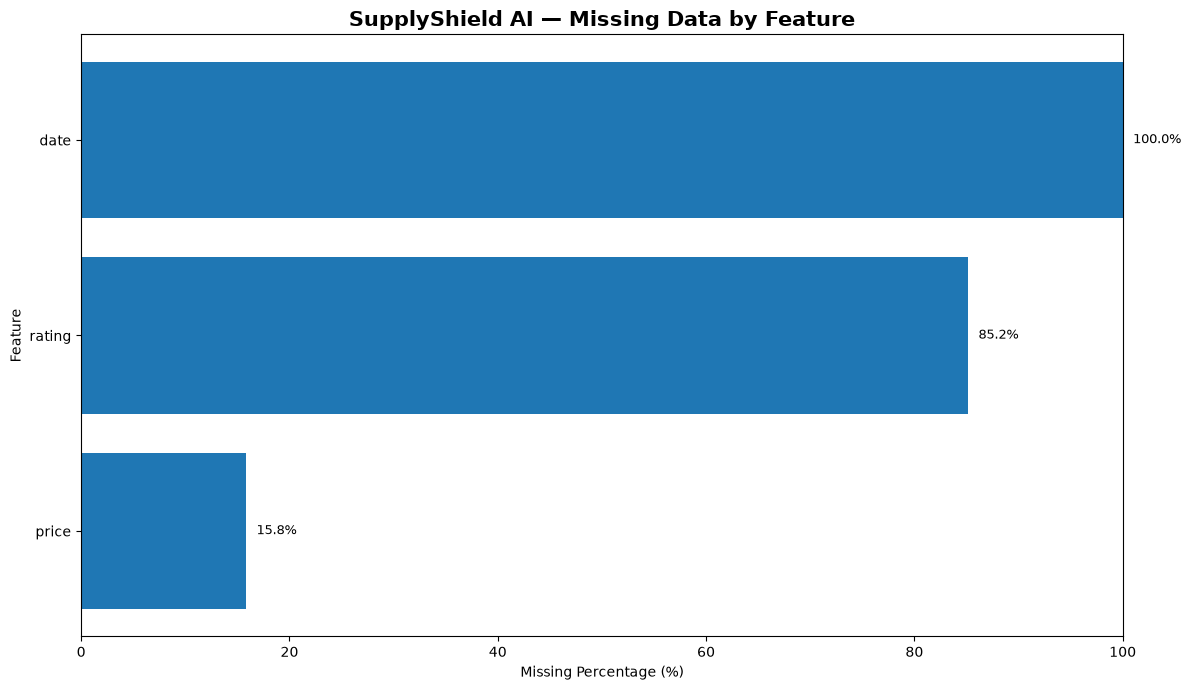

Saved: C:\Users\Pradeep Bhat\Documents\Hackathons\SupplyShield-AI\member2\outputs\figures\missing_data.png


In [6]:
# ============================================================
# MISSING DATA VISUALIZATION
# ============================================================

plot_data = (
    missing_analysis[
        missing_analysis["missing_count"] > 0
    ]
    .sort_values("missing_percentage", ascending=True)
)

if len(plot_data) > 0:

    fig, ax = plt.subplots(figsize=(12, 7))

    ax.barh(
        plot_data.index.astype(str),
        plot_data["missing_percentage"],
    )

    ax.set_title(
        "SupplyShield AI — Missing Data by Feature",
        fontsize=15,
        fontweight="bold",
    )

    ax.set_xlabel("Missing Percentage (%)")
    ax.set_ylabel("Feature")

    for index, value in enumerate(
        plot_data["missing_percentage"]
    ):
        ax.text(
            value + 1,
            index,
            f"{value:.1f}%",
            va="center",
            fontsize=9,
        )

    ax.set_xlim(
        0,
        min(
            100,
            max(plot_data["missing_percentage"].max() + 15, 20),
        ),
    )

    plt.tight_layout()

    figure_path = FIGURE_OUTPUT / "missing_data.png"
    plt.savefig(
        figure_path,
        dpi=200,
        bbox_inches="tight",
    )

    plt.show()

    print(f"Saved: {figure_path}")

else:
    print("No missing values detected.")

In [7]:
# ============================================================
# DATA QUALITY CLASSIFICATION
# ============================================================

def classify_data_completeness(percentage: float) -> str:
    """
    Classify feature completeness for downstream modeling.
    """

    if percentage >= 95:
        return "Excellent"

    if percentage >= 80:
        return "Good"

    if percentage >= 50:
        return "Moderate"

    if percentage >= 20:
        return "Low"

    return "Very Low"


quality_summary = missing_analysis.copy()

quality_summary["quality_level"] = (
    quality_summary["availability_percentage"]
    .apply(classify_data_completeness)
)

quality_summary = quality_summary.reset_index()

quality_summary = quality_summary[
    [
        "index",
        "available_count",
        "availability_percentage",
        "missing_count",
        "missing_percentage",
        "quality_level",
    ]
].rename(
    columns={"index": "feature"}
)

display(quality_summary)

quality_summary.to_csv(
    EDA_OUTPUT / "feature_quality_summary.csv",
    index=False,
)

,feature,available_count,availability_percentage,missing_count,missing_percentage,quality_level
0,date,0,0.000,303,100.000,Very Low
1,rating,45,14.850,258,85.150,Very Low
2,price,255,84.160,48,15.840,Good
3,supplier,303,100.000,0,0.000,Excellent
4,source,303,100.000,0,0.000,Excellent
5,title,303,100.000,0,0.000,Excellent
6,company,303,100.000,0,0.000,Excellent
7,location,303,100.000,0,0.000,Excellent
8,event,303,100.000,0,0.000,Excellent
9,product,303,100.000,0,0.000,Excellent


## 3. Source and Market Coverage

In [8]:
# ============================================================
# SOURCE DISTRIBUTION ANALYSIS
# ============================================================

source_analysis = (
    df["source"]
    .fillna("UNKNOWN")
    .astype(str)
    .str.strip()
    .replace("", "UNKNOWN")
    .value_counts()
    .rename_axis("source")
    .reset_index(name="record_count")
)

source_analysis["percentage"] = (
    source_analysis["record_count"]
    / len(df)
    * 100
).round(2)

source_analysis["cumulative_percentage"] = (
    source_analysis["percentage"]
    .cumsum()
    .round(2)
)

display(source_analysis)

source_analysis.to_csv(
    EDA_OUTPUT / "source_distribution.csv",
    index=False,
)

,source,record_count,percentage,cumulative_percentage
0,TradeIndia,247,81.520,81.520
1,Meesho,40,13.200,94.720
2,DeoDap,16,5.280,100.000


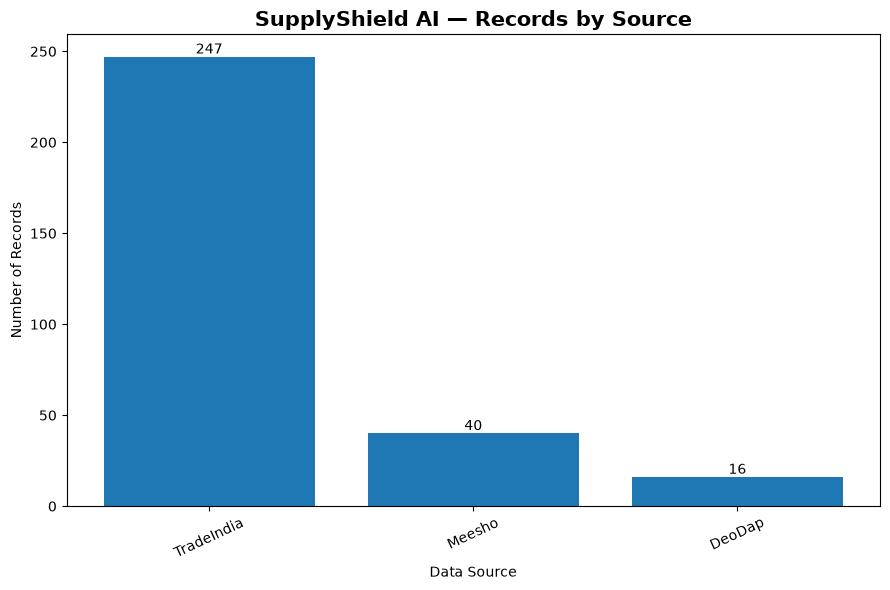

Saved: C:\Users\Pradeep Bhat\Documents\Hackathons\SupplyShield-AI\member2\outputs\figures\source_distribution.png


In [9]:
# ============================================================
# SOURCE DISTRIBUTION VISUALIZATION
# ============================================================

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.bar(
    source_analysis["source"],
    source_analysis["record_count"],
)

ax.set_title(
    "SupplyShield AI — Records by Source",
    fontsize=15,
    fontweight="bold",
)

ax.set_xlabel("Data Source")
ax.set_ylabel("Number of Records")

ax.tick_params(axis="x", rotation=25)

for bar, count in zip(
    bars,
    source_analysis["record_count"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(count),
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.tight_layout()

figure_path = FIGURE_OUTPUT / "source_distribution.png"

plt.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(f"Saved: {figure_path}")

In [10]:
# ============================================================
# SOURCE-LEVEL DATA QUALITY
# ============================================================

important_fields = [
    column
    for column in [
        "title",
        "company",
        "product",
        "price",
        "currency",
        "availability",
        "rating",
        "review",
        "date",
        "url",
        "timestamp",
    ]
    if column in df.columns
]

source_quality = []

for source, group in df.groupby(
    "source",
    dropna=False,
):

    source_name = (
        "UNKNOWN"
        if pd.isna(source)
        else str(source)
    )

    row = {
        "source": source_name,
        "records": len(group),
    }

    for field in important_fields:

        completeness = (
            group[field].notna().mean() * 100
        )

        row[f"{field}_completeness_pct"] = round(
            completeness,
            2,
        )

    source_quality.append(row)

source_quality = pd.DataFrame(source_quality)

display(source_quality)

source_quality.to_csv(
    EDA_OUTPUT / "source_quality_matrix.csv",
    index=False,
)

,source,records,title_completeness_pct,company_completeness_pct,product_completeness_pct,price_completeness_pct,currency_completeness_pct,availability_completeness_pct,rating_completeness_pct,review_completeness_pct,date_completeness_pct,url_completeness_pct,timestamp_completeness_pct
0,DeoDap,16,100.000,100.000,100.000,100.000,100.000,100.000,100.000,100.000,0.000,100.000,100.000
1,Meesho,40,100.000,100.000,100.000,100.000,100.000,100.000,72.500,100.000,0.000,100.000,100.000
2,TradeIndia,247,100.000,100.000,100.000,80.570,100.000,100.000,0.000,100.000,0.000,100.000,100.000


In [11]:
# ============================================================
# SOURCE CONTRIBUTION AND CONCENTRATION
# ============================================================

total_records = len(df)

source_concentration = source_analysis.copy()

source_concentration["share"] = (
    source_concentration["record_count"]
    / total_records
)

# Herfindahl-Hirschman-style concentration measure
# Used here descriptively to understand source concentration.
source_hhi = (
    source_concentration["share"] ** 2
).sum()

largest_source = source_concentration.iloc[0]

print("=" * 80)
print("SOURCE CONCENTRATION")
print("=" * 80)

print(
    f"\nLargest source       : {largest_source['source']}"
)

print(
    f"Largest source share : "
    f"{largest_source['percentage']:.2f}%"
)

print(
    f"Source concentration : "
    f"{source_hhi:.4f}"
)

print(
    "\nInterpretation:"
)

if largest_source["percentage"] > 70:
    print(
        "The dataset is strongly concentrated in one source. "
        "Cross-source validation is important before model deployment."
    )
elif largest_source["percentage"] > 50:
    print(
        "The dataset has moderate source concentration. "
        "Source-aware modeling should be considered."
    )
else:
    print(
        "The dataset has relatively balanced source coverage."
    )

SOURCE CONCENTRATION

Largest source       : TradeIndia
Largest source share : 81.52%
Source concentration : 0.6847

Interpretation:
The dataset is strongly concentrated in one source. Cross-source validation is important before model deployment.


## 4. Product and Company Intelligence

In [12]:
# ============================================================
# PRODUCT INTELLIGENCE
# ============================================================

def normalized_text_series(series: pd.Series) -> pd.Series:
    return (
        series
        .fillna("")
        .astype(str)
        .str.strip()
        .replace("", pd.NA)
    )


if "product" in df.columns:

    df["product_clean"] = normalized_text_series(
        df["product"]
    )

    product_counts = (
        df["product_clean"]
        .dropna()
        .value_counts()
        .rename_axis("product")
        .reset_index(name="record_count")
    )

    product_counts["percentage"] = (
        product_counts["record_count"]
        / len(df)
        * 100
    ).round(2)

    print("Unique products:", df["product_clean"].nunique())

    print("\nTop products:")
    display(product_counts.head(20))

    product_counts.to_csv(
        EDA_OUTPUT / "product_frequency.csv",
        index=False,
    )

else:
    product_counts = pd.DataFrame()
    print("Product field not available.")

Unique products: 288

Top products:


,product,record_count,percentage
0,Simple Auxanometer,3,0.990
1,Broken Bag Detector,3,0.990
2,Crane Cable Trolley,2,0.660
3,Air Pump,2,0.660
4,Heat Resistant Conveyor Belt,2,0.660
5,Siemens Artis Zee Cath Lab,2,0.660
6,Air Slide,2,0.660
7,Fruit Hardness Tester,2,0.660
8,Open Air Slide,2,0.660
9,Hydraulic Pallet Truck,2,0.660


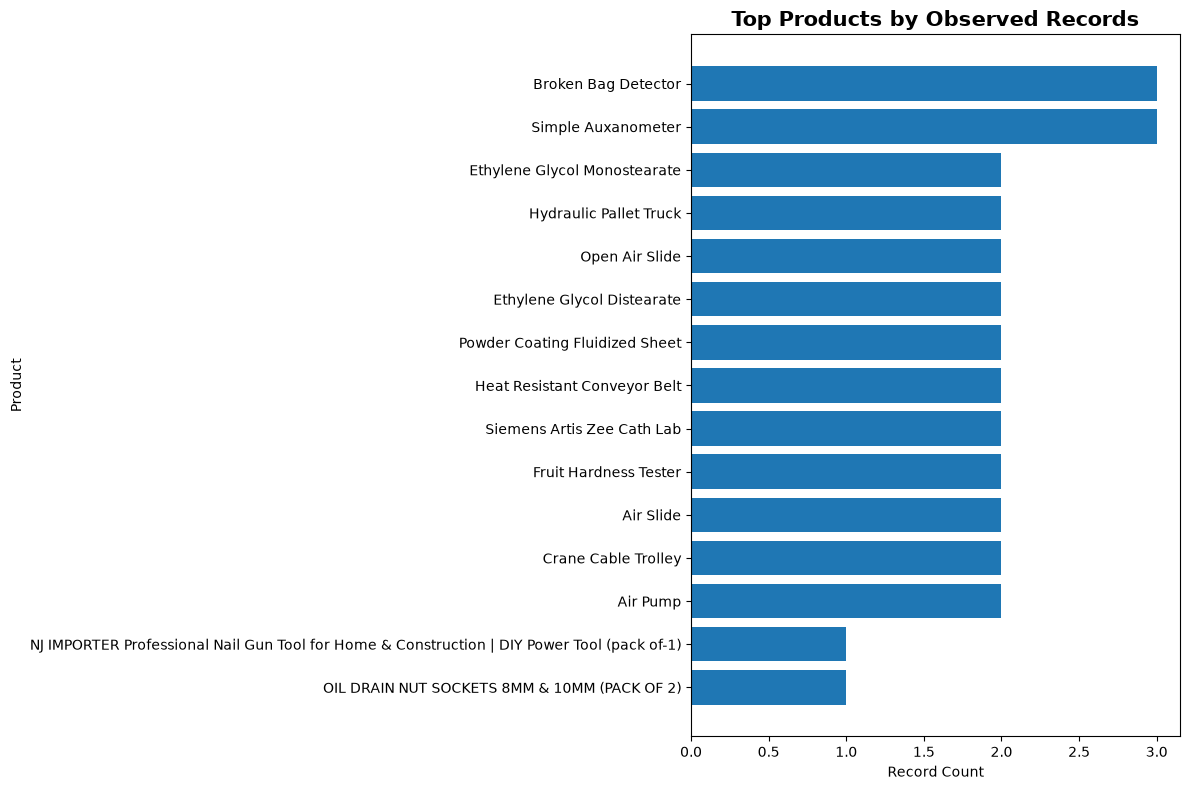

Saved: C:\Users\Pradeep Bhat\Documents\Hackathons\SupplyShield-AI\member2\outputs\figures\top_products.png


In [13]:
# ============================================================
# TOP PRODUCT VISUALIZATION
# ============================================================

if not product_counts.empty:

    top_products = (
        product_counts
        .head(15)
        .sort_values("record_count")
    )

    fig, ax = plt.subplots(figsize=(12, 8))

    ax.barh(
        top_products["product"].astype(str),
        top_products["record_count"],
    )

    ax.set_title(
        "Top Products by Observed Records",
        fontsize=15,
        fontweight="bold",
    )

    ax.set_xlabel("Record Count")
    ax.set_ylabel("Product")

    plt.tight_layout()

    figure_path = FIGURE_OUTPUT / "top_products.png"

    plt.savefig(
        figure_path,
        dpi=200,
        bbox_inches="tight",
    )

    plt.show()

    print(f"Saved: {figure_path}")

In [14]:
# ============================================================
# COMPANY / SELLER ANALYSIS
# ============================================================

if "company" in df.columns:

    df["company_clean"] = normalized_text_series(
        df["company"]
    )

    company_counts = (
        df["company_clean"]
        .dropna()
        .value_counts()
        .rename_axis("company")
        .reset_index(name="record_count")
    )

    company_counts["percentage"] = (
        company_counts["record_count"]
        / len(df)
        * 100
    ).round(2)

    print(
        "Unique companies:",
        df["company_clean"].nunique()
    )

    print("\nTop companies:")
    display(company_counts.head(20))

    company_counts.to_csv(
        EDA_OUTPUT / "company_frequency.csv",
        index=False,
    )

else:
    company_counts = pd.DataFrame()
    print("Company field not available.")

Unique companies: 273

Top companies:


,company,record_count,percentage
0,DeoDap,12,3.960
1,Edutek Instrumentation,5,1.650
2,Esel International,3,0.990
3,Triveni Interchem Pvt. Ltd.,3,0.990
4,Aditya Agency,2,0.660
5,J. C. Gupta & Sons,2,0.660
6,Ar Industries,2,0.660
7,Asten Controls Llp,2,0.660
8,Cynor Laboratories,2,0.660
9,Deodap,2,0.660


In [15]:
# ============================================================
# TEXT-BASED PRODUCT FEATURES
# ============================================================

text_candidates = [
    column
    for column in [
        "title",
        "product",
        "company",
        "review",
    ]
    if column in df.columns
]

for column in text_candidates:

    text = (
        df[column]
        .fillna("")
        .astype(str)
        .str.strip()
    )

    df[f"{column}_char_count"] = text.str.len()

    df[f"{column}_word_count"] = (
        text.str.split()
        .str.len()
    )

text_feature_columns = [
    column
    for column in df.columns
    if column.endswith("_char_count")
    or column.endswith("_word_count")
]

text_feature_summary = (
    df[text_feature_columns]
    .describe()
    .T
    if text_feature_columns
    else pd.DataFrame()
)

display(text_feature_summary)

if not text_feature_summary.empty:

    text_feature_summary.to_csv(
        EDA_OUTPUT / "text_feature_summary.csv"
    )

,count,mean,std,min,25%,50%,75%,max
title_char_count,303.000,68.554,45.798,7.000,37.000,52.000,91.000,246.000
title_word_count,303.000,10.670,6.969,2.000,6.000,8.000,14.000,37.000
product_char_count,303.000,40.594,35.793,4.000,21.000,28.000,47.000,246.000
product_word_count,303.000,6.376,5.768,1.000,3.000,4.000,7.000,37.000
company_char_count,303.000,20.845,9.213,6.000,14.000,19.000,27.000,52.000
company_word_count,303.000,2.914,1.319,1.000,2.000,3.000,4.000,6.000
review_char_count,303.000,15.132,54.687,0.000,0.000,0.000,0.000,249.000
review_word_count,303.000,2.683,9.358,0.000,0.000,0.000,0.000,42.000


## 5. Price and Market Signal Analysis

In [16]:
# ============================================================
# PRICE ANALYSIS
# ============================================================

if "price" in df.columns:

    price = pd.to_numeric(
        df["price"],
        errors="coerce",
    )

    valid_price = price.dropna()

    price_summary = pd.DataFrame({
        "metric": [
            "count",
            "missing",
            "mean",
            "median",
            "std",
            "minimum",
            "25th_percentile",
            "75th_percentile",
            "maximum",
        ],
        "value": [
            int(valid_price.count()),
            int(price.isna().sum()),
            float(valid_price.mean()) if len(valid_price) else np.nan,
            float(valid_price.median()) if len(valid_price) else np.nan,
            float(valid_price.std()) if len(valid_price) > 1 else np.nan,
            float(valid_price.min()) if len(valid_price) else np.nan,
            float(valid_price.quantile(0.25)) if len(valid_price) else np.nan,
            float(valid_price.quantile(0.75)) if len(valid_price) else np.nan,
            float(valid_price.max()) if len(valid_price) else np.nan,
        ],
    })

    display(price_summary)

    price_summary.to_csv(
        EDA_OUTPUT / "price_summary.csv",
        index=False,
    )

else:
    price = pd.Series(dtype=float)
    valid_price = price
    print("Price field not available.")

,metric,value
0,count,255.000
1,missing,48.000
2,mean,"207,897.846"
3,median,950.000
4,std,"1,598,459.632"
5,minimum,0.500
6,25th_percentile,170.000
7,75th_percentile,"17,600.000"
8,maximum,"15,340,000.000"


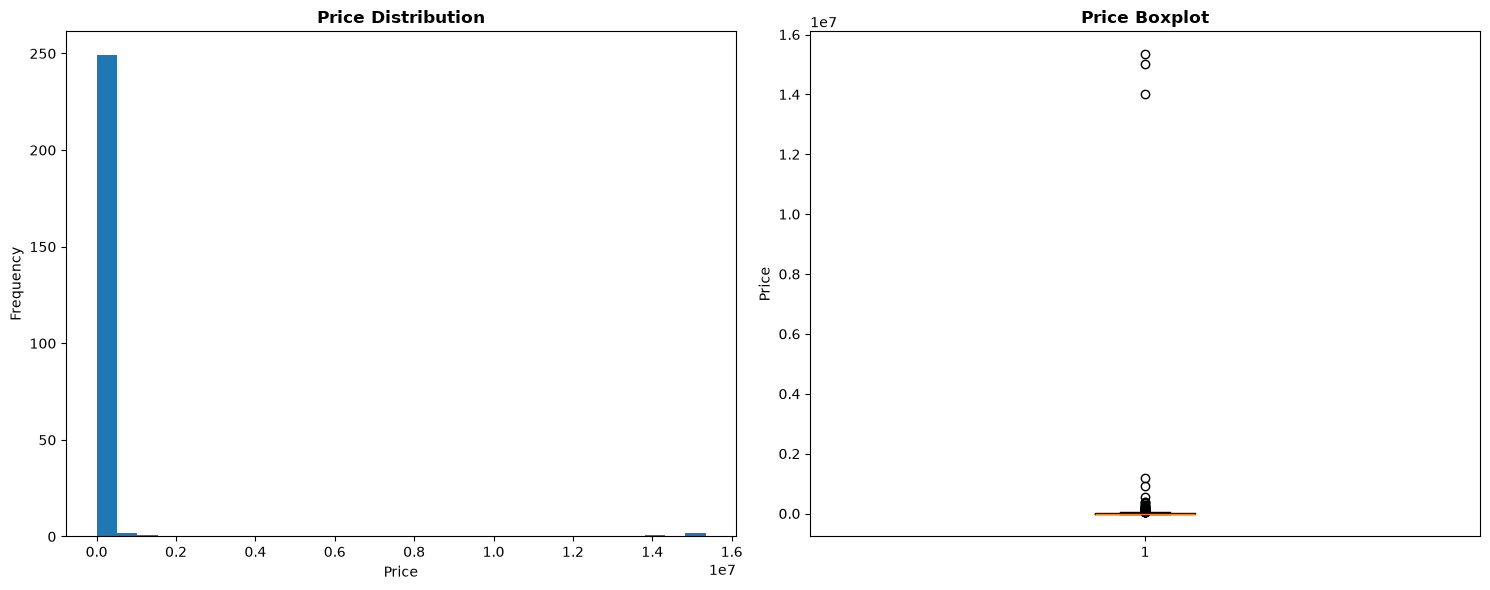

Saved: C:\Users\Pradeep Bhat\Documents\Hackathons\SupplyShield-AI\member2\outputs\figures\price_distribution.png


In [17]:
# ============================================================
# PRICE DISTRIBUTION
# ============================================================

if len(valid_price) > 0:

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(15, 6),
    )

    axes[0].hist(
        valid_price,
        bins=30,
    )

    axes[0].set_title(
        "Price Distribution",
        fontweight="bold",
    )

    axes[0].set_xlabel("Price")
    axes[0].set_ylabel("Frequency")

    axes[1].boxplot(
        valid_price,
        vert=True,
    )

    axes[1].set_title(
        "Price Boxplot",
        fontweight="bold",
    )

    axes[1].set_ylabel("Price")

    plt.tight_layout()

    figure_path = FIGURE_OUTPUT / "price_distribution.png"

    plt.savefig(
        figure_path,
        dpi=200,
        bbox_inches="tight",
    )

    plt.show()

    print(f"Saved: {figure_path}")

In [18]:
# ============================================================
# STATISTICAL PRICE OUTLIER DETECTION
# ============================================================

if len(valid_price) >= 4:

    q1 = valid_price.quantile(0.25)
    q3 = valid_price.quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    df["price_iqr_outlier"] = False

    df.loc[
        df["price"].notna(),
        "price_iqr_outlier"
    ] = (
        (df.loc[df["price"].notna(), "price"] < lower_bound)
        |
        (df.loc[df["price"].notna(), "price"] > upper_bound)
    )

    outlier_count = int(
        df["price_iqr_outlier"].sum()
    )

    print("=" * 80)
    print("PRICE OUTLIER ANALYSIS")
    print("=" * 80)

    print(f"\nQ1                  : {q1:,.2f}")
    print(f"Q3                  : {q3:,.2f}")
    print(f"IQR                 : {iqr:,.2f}")
    print(f"Lower bound         : {lower_bound:,.2f}")
    print(f"Upper bound         : {upper_bound:,.2f}")
    print(f"IQR outliers        : {outlier_count:,}")
    print(
        f"Outlier percentage  : "
        f"{outlier_count / len(df) * 100:.2f}%"
    )

    price_outliers = (
        df[df["price_iqr_outlier"]]
        .sort_values("price", ascending=False)
        .copy()
    )

    display(
        price_outliers[
            [
                column
                for column in [
                    "source",
                    "title",
                    "product",
                    "company",
                    "price",
                    "currency",
                    "url",
                ]
                if column in price_outliers.columns
            ]
        ].head(25)
    )

    price_outliers.to_csv(
        EDA_OUTPUT / "statistical_price_outliers.csv",
        index=False,
    )

else:
    print("Insufficient valid price observations for IQR analysis.")

PRICE OUTLIER ANALYSIS

Q1                  : 170.00
Q3                  : 17,600.00
IQR                 : 17,430.00
Lower bound         : -25,975.00
Upper bound         : 43,745.00
IQR outliers        : 38
Outlier percentage  : 12.54%


,source,title,product,company,price,currency,url
127,TradeIndia,Allenger Altima F100 Fixed Cath Lab Machine,Allenger Altima F100 Fixed Cath Lab Machine,Rentomed,"15,340,000.000",INR,https://www.tradeindia.com/products/allenger-a...
238,TradeIndia,Cath Lab Machine,Cath Lab Machine,Mf India,"15,000,000.000",INR,https://www.tradeindia.com/products/cath-lab-m...
99,TradeIndia,Siemens Artis Zee Cath Lab - Application: Hosp...,Siemens Artis Zee Cath Lab,Arihant Medmach Private Limited,"14,000,000.000",INR,https://www.tradeindia.com/products/siemens-ar...
218,TradeIndia,Front Belt 10 Bricks Making Machine - Feature:...,Front Belt 10 Bricks Making Machine,Kabir Industrial Technology,"1,200,000.000",INR,https://www.tradeindia.com/products/front-belt...
102,TradeIndia,"Mini Dumper - Mild Steel Construction, Yellow ...",Mini Dumper,Vpg Buildwell India Pvt. Ltd.,"914,500.000",INR,https://www.tradeindia.com/products/commercial...
173,TradeIndia,"Multi Head Cnc Drill Machine - Metal, 2300mm X...",Multi Head Cnc Drill Machine,Mould Well,"550,000.000",INR,https://www.tradeindia.com/products/multi-head...
227,TradeIndia,Davis Tube Tester,Davis Tube Tester,Eloquent Technology,"400,000.000",INR,https://www.tradeindia.com/products/davis-tube...
106,TradeIndia,Green Equotip Bambino 2 Portable Hardness Tester,Green Equotip Bambino 2 Portable Hardness Tester,Dhara Agency,"383,500.000",INR,https://www.tradeindia.com/products/equotip-ba...
49,TradeIndia,200cm Slow Speed Rapier - Color: Green,200cm Slow Speed Rapier,Aaria International,"350,000.000",INR,https://www.tradeindia.com/products/200cm-slow...
66,TradeIndia,Equotip 3 Portable Hardness Tester By Testing ...,Equotip 3 Portable Hardness Tester By Testing ...,Testing & Measuring Equipments,"290,000.000",INR,https://www.tradeindia.com/products/equotip-3-...


,source,record_count,mean_price,median_price,minimum_price,maximum_price,std_price
0,DeoDap,16,144.440,108.000,1.000,400.000,138.010
1,Meesho,40,276.750,214.000,48.000,786.000,162.520
2,TradeIndia,199,"266,334.520","2,565.000",0.500,"15,340,000.000","1,806,126.210"


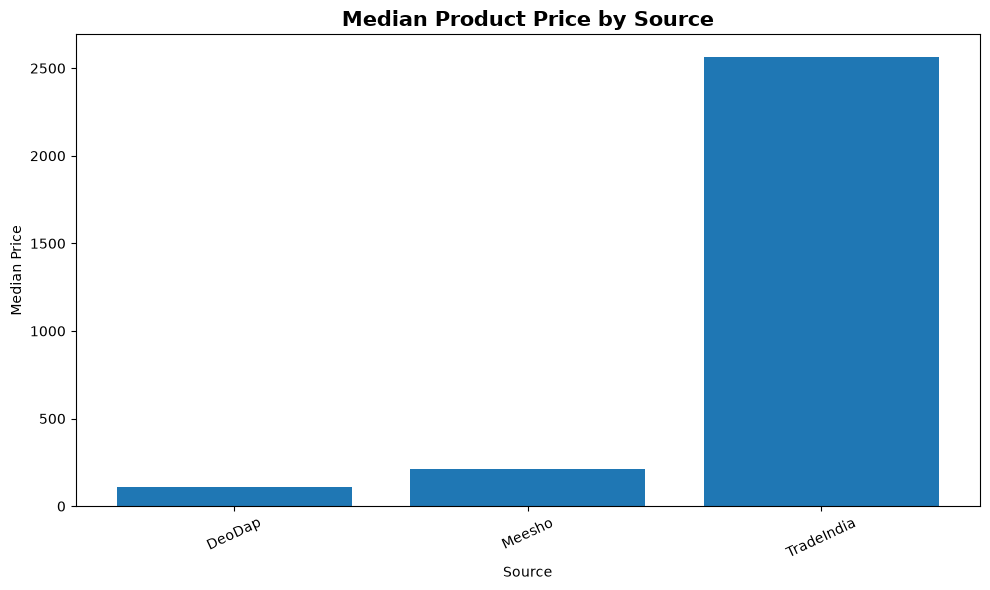

Saved: C:\Users\Pradeep Bhat\Documents\Hackathons\SupplyShield-AI\member2\outputs\figures\median_price_by_source.png


In [19]:
# ============================================================
# PRICE COMPARISON ACROSS SOURCES
# ============================================================

if "source" in df.columns and "price" in df.columns:

    source_price = (
        df
        .dropna(subset=["price"])
        .groupby("source")["price"]
        .agg(
            record_count="count",
            mean_price="mean",
            median_price="median",
            minimum_price="min",
            maximum_price="max",
            std_price="std",
        )
        .reset_index()
    )

    for column in [
        "mean_price",
        "median_price",
        "minimum_price",
        "maximum_price",
        "std_price",
    ]:
        source_price[column] = source_price[column].round(2)

    display(source_price)

    source_price.to_csv(
        EDA_OUTPUT / "source_price_analysis.csv",
        index=False,
    )

    # Visualization
    fig, ax = plt.subplots(figsize=(10, 6))

    ax.bar(
        source_price["source"].astype(str),
        source_price["median_price"],
    )

    ax.set_title(
        "Median Product Price by Source",
        fontsize=15,
        fontweight="bold",
    )

    ax.set_xlabel("Source")
    ax.set_ylabel("Median Price")

    plt.xticks(rotation=25)

    plt.tight_layout()

    figure_path = FIGURE_OUTPUT / "median_price_by_source.png"

    plt.savefig(
        figure_path,
        dpi=200,
        bbox_inches="tight",
    )

    plt.show()

    print(f"Saved: {figure_path}")

## 6. Availability, Reviews and Temporal Signals

In [20]:
# ============================================================
# AVAILABILITY ANALYSIS
# ============================================================

if "availability" in df.columns:

    availability_clean = (
        df["availability"]
        .fillna("")
        .astype(str)
        .str.strip()
    )

    availability_summary = pd.DataFrame({
        "availability_value": (
            availability_clean
            .replace("", "MISSING")
            .value_counts()
            .index
        ),
        "record_count": (
            availability_clean
            .replace("", "MISSING")
            .value_counts()
            .values
        ),
    })

    availability_summary["percentage"] = (
        availability_summary["record_count"]
        / len(df)
        * 100
    ).round(2)

    display(
        availability_summary.head(30)
    )

    availability_summary.to_csv(
        EDA_OUTPUT / "availability_distribution.csv",
        index=False,
    )

else:
    availability_summary = pd.DataFrame()
    print("Availability field not available.")

,availability_value,record_count,percentage
0,in_stock,287,94.720
1,MISSING,16,5.280


In [21]:
# ============================================================
# AVAILABILITY SEMANTIC NORMALIZATION
# ============================================================

def classify_availability(value: object) -> str:
    """
    Convert heterogeneous marketplace availability text
    into a normalized business category.
    """

    if pd.isna(value):
        return "Unknown"

    text = str(value).strip().lower()

    if not text:
        return "Unknown"

    # Explicit stock signals
    if any(
        keyword in text
        for keyword in [
            "out of stock",
            "unavailable",
            "sold out",
            "not available",
        ]
    ):
        return "Out of Stock"

    if any(
        keyword in text
        for keyword in [
            "in stock",
            "available",
            "ready stock",
            "instock",
        ]
    ):
        return "Available"

    # Quantity-like information
    if any(
        keyword in text
        for keyword in [
            "left",
            "remaining",
            "pieces",
            "units",
            "quantity",
        ]
    ):
        return "Quantity Signal"

    return "Unclassified"


if "availability" in df.columns:

    df["availability_category"] = (
        df["availability"]
        .apply(classify_availability)
    )

    availability_categories = (
        df["availability_category"]
        .value_counts()
        .rename_axis("availability_category")
        .reset_index(name="record_count")
    )

    availability_categories["percentage"] = (
        availability_categories["record_count"]
        / len(df)
        * 100
    ).round(2)

    display(availability_categories)

    availability_categories.to_csv(
        EDA_OUTPUT / "availability_categories.csv",
        index=False,
    )

,availability_category,record_count,percentage
0,Unclassified,287,94.720
1,Unknown,16,5.280


In [22]:
# ============================================================
# REVIEW DATA ANALYSIS
# ============================================================

if "review" in df.columns:

    review_text = (
        df["review"]
        .fillna("")
        .astype(str)
        .str.strip()
    )

    df["has_review"] = review_text.ne("")

    df["review_char_count"] = review_text.str.len()

    df["review_word_count"] = (
        review_text
        .str.split()
        .str.len()
    )

    review_summary = pd.DataFrame({
        "metric": [
            "records",
            "records_with_review",
            "records_without_review",
            "review_coverage_percentage",
            "average_review_characters",
            "median_review_characters",
            "average_review_words",
            "median_review_words",
        ],
        "value": [
            len(df),
            int(df["has_review"].sum()),
            int((~df["has_review"]).sum()),
            round(df["has_review"].mean() * 100, 2),
            round(
                df.loc[
                    df["has_review"],
                    "review_char_count"
                ].mean(),
                2,
            ),
            round(
                df.loc[
                    df["has_review"],
                    "review_char_count"
                ].median(),
                2,
            ),
            round(
                df.loc[
                    df["has_review"],
                    "review_word_count"
                ].mean(),
                2,
            ),
            round(
                df.loc[
                    df["has_review"],
                    "review_word_count"
                ].median(),
                2,
            ),
        ],
    })

    display(review_summary)

    review_summary.to_csv(
        EDA_OUTPUT / "review_summary.csv",
        index=False,
    )

else:
    print("Review field not available.")

,metric,value
0,records,303.000
1,records_with_review,45.000
2,records_without_review,258.000
3,review_coverage_percentage,14.850
4,average_review_characters,101.890
5,median_review_characters,25.000
6,average_review_words,18.070
7,median_review_words,5.000


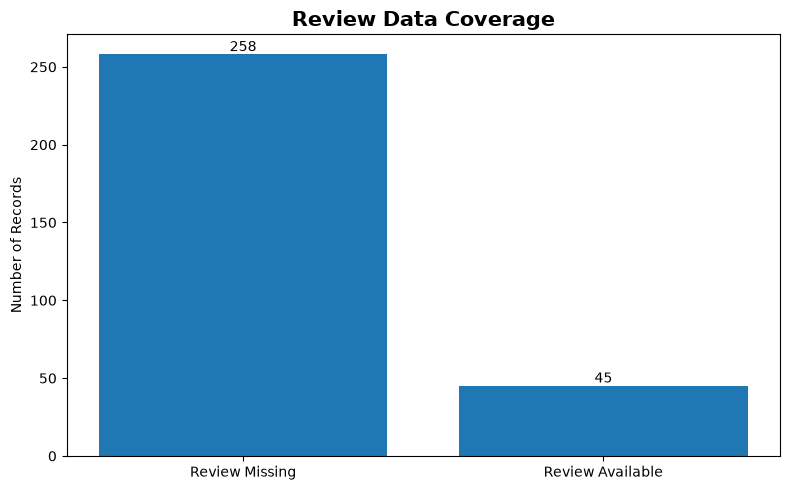

Saved: C:\Users\Pradeep Bhat\Documents\Hackathons\SupplyShield-AI\member2\outputs\figures\review_coverage.png


In [23]:
# ============================================================
# REVIEW COVERAGE VISUALIZATION
# ============================================================

if "has_review" in df.columns:

    review_counts = (
        df["has_review"]
        .map({
            True: "Review Available",
            False: "Review Missing",
        })
        .value_counts()
    )

    fig, ax = plt.subplots(figsize=(8, 5))

    bars = ax.bar(
        review_counts.index,
        review_counts.values,
    )

    ax.set_title(
        "Review Data Coverage",
        fontsize=15,
        fontweight="bold",
    )

    ax.set_ylabel("Number of Records")

    for bar, value in zip(
        bars,
        review_counts.values,
    ):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            str(value),
            ha="center",
            va="bottom",
        )

    plt.tight_layout()

    figure_path = FIGURE_OUTPUT / "review_coverage.png"

    plt.savefig(
        figure_path,
        dpi=200,
        bbox_inches="tight",
    )

    plt.show()

    print(f"Saved: {figure_path}")

In [24]:
# ============================================================
# TEMPORAL COVERAGE ANALYSIS
# ============================================================

temporal_column = None

for candidate in ["timestamp", "date"]:
    if candidate in df.columns and df[candidate].notna().any():
        temporal_column = candidate
        break

if temporal_column:

    temporal_data = df[
        [temporal_column]
    ].dropna().copy()

    temporal_data["period"] = (
        temporal_data[temporal_column]
        .dt.date
    )

    daily_counts = (
        temporal_data["period"]
        .value_counts()
        .sort_index()
        .rename_axis("date")
        .reset_index(name="record_count")
    )

    print(
        f"Temporal analysis based on: {temporal_column}"
    )

    print(
        f"First observation: "
        f"{temporal_data[temporal_column].min()}"
    )

    print(
        f"Last observation : "
        f"{temporal_data[temporal_column].max()}"
    )

    display(daily_counts.head(20))

    daily_counts.to_csv(
        EDA_OUTPUT / "daily_record_volume.csv",
        index=False,
    )

else:
    daily_counts = pd.DataFrame()
    print("No usable temporal field detected.")

Temporal analysis based on: timestamp
First observation: 2026-08-19 18:04:23.947119+00:00
Last observation : 2026-08-19 18:04:23.968126+00:00


,date,record_count
0,2026-08-19,303


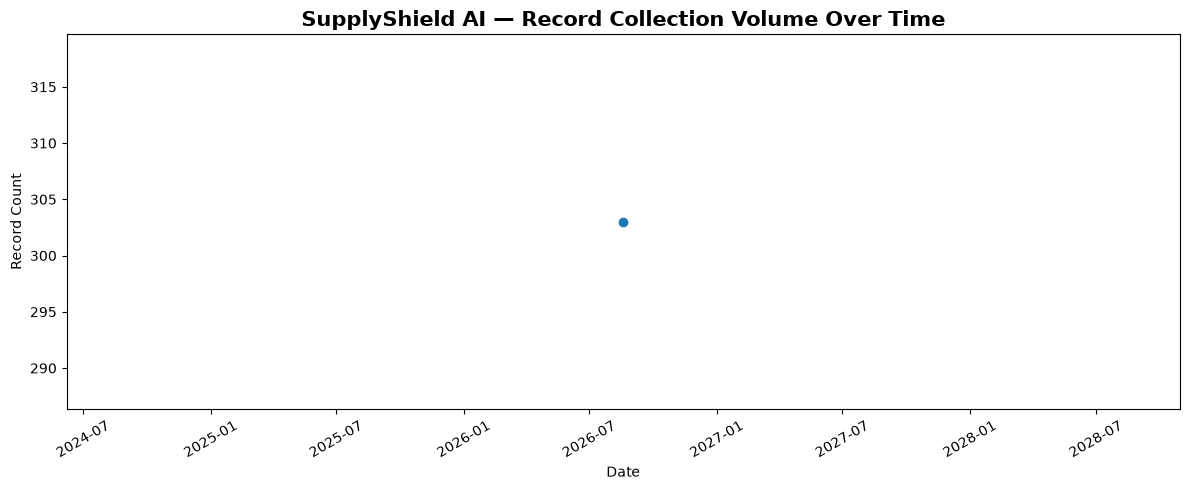

Saved: C:\Users\Pradeep Bhat\Documents\Hackathons\SupplyShield-AI\member2\outputs\figures\temporal_record_volume.png


In [25]:
# ============================================================
# TEMPORAL RECORD VOLUME
# ============================================================

if not daily_counts.empty:

    dates = pd.to_datetime(
        daily_counts["date"]
    )

    fig, ax = plt.subplots(figsize=(12, 5))

    ax.plot(
        dates,
        daily_counts["record_count"],
        marker="o",
        linewidth=2,
    )

    ax.set_title(
        "SupplyShield AI — Record Collection Volume Over Time",
        fontsize=15,
        fontweight="bold",
    )

    ax.set_xlabel("Date")
    ax.set_ylabel("Record Count")

    plt.xticks(rotation=30)

    plt.tight_layout()

    figure_path = FIGURE_OUTPUT / "temporal_record_volume.png"

    plt.savefig(
        figure_path,
        dpi=200,
        bbox_inches="tight",
    )

    plt.show()

    print(f"Saved: {figure_path}")

## 7. Cross-Feature Relationships and Anomaly Exploration

In [26]:
# ============================================================
# NUMERIC FEATURE RELATIONSHIPS
# ============================================================

numeric_columns = df.select_dtypes(
    include=[np.number]
).columns.tolist()

numeric_columns = [
    column
    for column in numeric_columns
    if not column.endswith("_char_count")
    and not column.endswith("_word_count")
]

if numeric_columns:

    numeric_summary = (
        df[numeric_columns]
        .describe()
        .T
        .reset_index()
        .rename(columns={"index": "feature"})
    )

    display(numeric_summary)

    numeric_summary.to_csv(
        EDA_OUTPUT / "numeric_feature_summary.csv",
        index=False,
    )

else:
    numeric_summary = pd.DataFrame()
    print("No numeric features available.")

,feature,count,mean,std,min,25%,50%,75%,max
0,price,255.000,"207,897.846","1,598,459.632",0.500,170.000,950.000,"17,600.000","15,340,000.000"
1,rating,45.000,4.197,0.447,3.100,3.900,4.200,4.570,5.000


,price,rating
price,1.000,-0.178
rating,-0.178,1.000


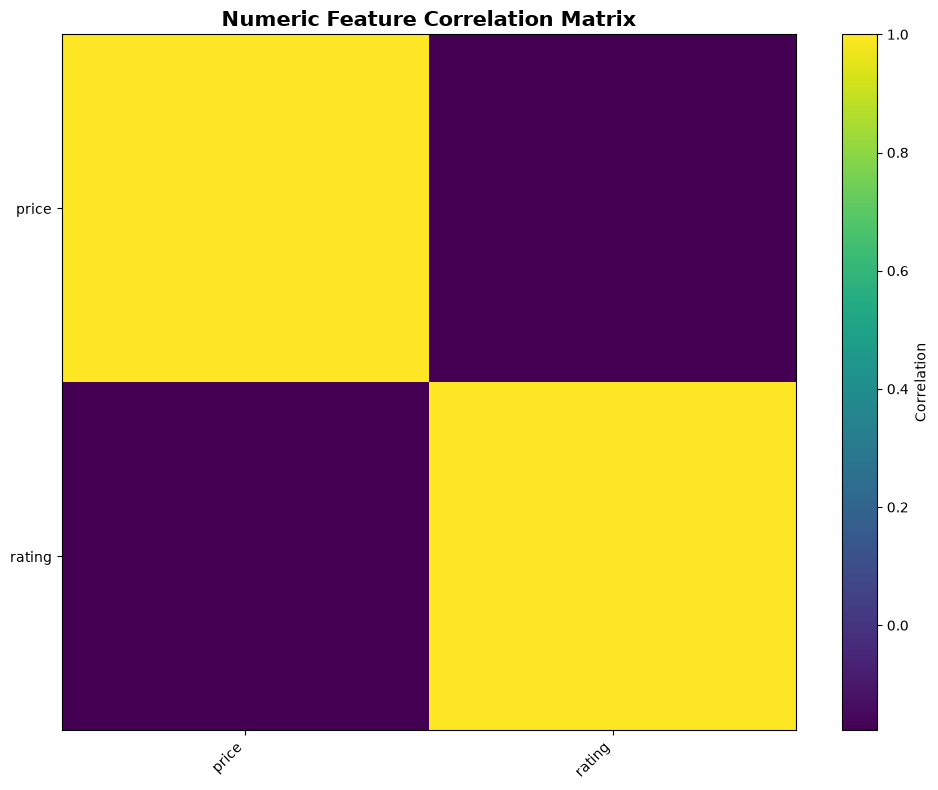

Saved: C:\Users\Pradeep Bhat\Documents\Hackathons\SupplyShield-AI\member2\outputs\figures\correlation_matrix.png


In [27]:
# ============================================================
# CORRELATION ANALYSIS
# ============================================================

if len(numeric_columns) >= 2:

    correlation_matrix = (
        df[numeric_columns]
        .corr(numeric_only=True)
    )

    display(correlation_matrix)

    correlation_matrix.to_csv(
        EDA_OUTPUT / "numeric_correlation_matrix.csv"
    )

    fig, ax = plt.subplots(
        figsize=(10, 8)
    )

    matrix = correlation_matrix.values

    image = ax.imshow(
        matrix,
        aspect="auto",
    )

    ax.set_xticks(
        range(len(correlation_matrix.columns))
    )

    ax.set_yticks(
        range(len(correlation_matrix.index))
    )

    ax.set_xticklabels(
        correlation_matrix.columns,
        rotation=45,
        ha="right",
    )

    ax.set_yticklabels(
        correlation_matrix.index
    )

    ax.set_title(
        "Numeric Feature Correlation Matrix",
        fontsize=15,
        fontweight="bold",
    )

    plt.colorbar(
        image,
        ax=ax,
        label="Correlation",
    )

    plt.tight_layout()

    figure_path = FIGURE_OUTPUT / "correlation_matrix.png"

    plt.savefig(
        figure_path,
        dpi=200,
        bbox_inches="tight",
    )

    plt.show()

    print(f"Saved: {figure_path}")

else:
    print(
        "At least two numeric features are required "
        "for correlation analysis."
    )

In [28]:
# ============================================================
# SOURCE × PRICE OUTLIER ANALYSIS
# ============================================================

if (
    "price_iqr_outlier" in df.columns
    and "source" in df.columns
):

    source_outlier_analysis = (
        df.groupby("source")
        .agg(
            total_records=("source", "size"),
            valid_prices=("price", "count"),
            price_outliers=("price_iqr_outlier", "sum"),
        )
        .reset_index()
    )

    source_outlier_analysis["outlier_rate_pct"] = np.where(
        source_outlier_analysis["valid_prices"] > 0,
        source_outlier_analysis["price_outliers"]
        / source_outlier_analysis["valid_prices"]
        * 100,
        0,
    ).round(2)

    display(source_outlier_analysis)

    source_outlier_analysis.to_csv(
        EDA_OUTPUT / "source_price_outlier_analysis.csv",
        index=False,
    )

,source,total_records,valid_prices,price_outliers,outlier_rate_pct
0,DeoDap,16,16,0,0.000
1,Meesho,40,40,0,0.000
2,TradeIndia,247,199,38,19.100


In [29]:
# ============================================================
# MEMBER 1 ANOMALY OUTPUT COMPARISON
# ============================================================

member1_anomaly_path = (
    PROJECT_ROOT
    / "member1"
    / "supply-webshield"
    / "data"
    / "rejected"
    / "price_anomalies.json"
)

if member1_anomaly_path.exists():

    try:

        with member1_anomaly_path.open(
            "r",
            encoding="utf-8",
        ) as file:
            member1_anomalies = json.load(file)

        member1_anomaly_count = (
            len(member1_anomalies)
            if isinstance(member1_anomalies, list)
            else 0
        )

        statistical_outlier_count = (
            int(df["price_iqr_outlier"].sum())
            if "price_iqr_outlier" in df.columns
            else 0
        )

        comparison = pd.DataFrame({
            "analysis_layer": [
                "Member 1 pipeline",
                "Member 2 statistical EDA",
            ],
            "method": [
                "Existing pipeline anomaly detector",
                "IQR statistical outlier detection",
            ],
            "flagged_records": [
                member1_anomaly_count,
                statistical_outlier_count,
            ],
        })

        display(comparison)

        comparison.to_csv(
            EDA_OUTPUT / "anomaly_method_comparison.csv",
            index=False,
        )

        print(
            "\nImportant:"
            "\nThese two counts should NOT be expected to match."
            "\nThey represent different anomaly-detection methods."
        )

    except Exception as exc:

        print(
            f"Could not read Member 1 anomaly file: {exc}"
        )

else:

    print(
        "Member 1 anomaly file was not found."
    )

,analysis_layer,method,flagged_records
0,Member 1 pipeline,Existing pipeline anomaly detector,54
1,Member 2 statistical EDA,IQR statistical outlier detection,38



Important:
These two counts should NOT be expected to match.
They represent different anomaly-detection methods.


## 8. Feature Engineering Readiness

In [30]:
# ============================================================
# MEMBER 2 FEATURE ENGINEERING FOUNDATION
# ============================================================

feature_df = df.copy()

# ------------------------------------------------------------
# Price features
# ------------------------------------------------------------

if "price" in feature_df.columns:

    feature_df["price_numeric"] = pd.to_numeric(
        feature_df["price"],
        errors="coerce",
    )

    # Log transform is useful for heavily right-skewed prices.
    feature_df["price_log1p"] = np.log1p(
        feature_df["price_numeric"].clip(lower=0)
    )

    median_price = feature_df["price_numeric"].median()

    if pd.notna(median_price) and median_price > 0:

        feature_df["price_deviation_from_median"] = (
            feature_df["price_numeric"]
            / median_price
        )

    else:

        feature_df["price_deviation_from_median"] = np.nan


# ------------------------------------------------------------
# Text features
# ------------------------------------------------------------

for column in [
    "title",
    "product",
    "company",
    "review",
]:

    if column in feature_df.columns:

        text = (
            feature_df[column]
            .fillna("")
            .astype(str)
            .str.strip()
        )

        feature_df[f"{column}_length"] = (
            text.str.len()
        )

        feature_df[f"{column}_word_count"] = (
            text.str.split()
            .str.len()
        )


# ------------------------------------------------------------
# Review signal
# ------------------------------------------------------------

if "review" in feature_df.columns:

    feature_df["review_available"] = (
        feature_df["review"]
        .fillna("")
        .astype(str)
        .str.strip()
        .ne("")
        .astype(int)
    )


# ------------------------------------------------------------
# Availability signal
# ------------------------------------------------------------

if "availability_category" in feature_df.columns:

    feature_df["availability_unknown"] = (
        feature_df["availability_category"]
        .eq("Unknown")
        .astype(int)
    )

    feature_df["availability_unclassified"] = (
        feature_df["availability_category"]
        .eq("Unclassified")
        .astype(int)
    )


# ------------------------------------------------------------
# Data confidence features
# ------------------------------------------------------------

important_fields = [
    column
    for column in [
        "title",
        "company",
        "product",
        "price",
        "currency",
        "availability",
        "rating",
        "review",
        "url",
        "timestamp",
    ]
    if column in feature_df.columns
]

feature_df["data_completeness_score"] = (
    feature_df[important_fields]
    .notna()
    .mean(axis=1)
    * 100
).round(2)

# ------------------------------------------------------------
# Source encoding
# ------------------------------------------------------------

if "source" in feature_df.columns:

    source_frequency = (
        feature_df["source"]
        .value_counts(normalize=True)
    )

    feature_df["source_frequency"] = (
        feature_df["source"]
        .map(source_frequency)
        .fillna(0)
    )

# ------------------------------------------------------------
# Display engineered features
# ------------------------------------------------------------

engineered_columns = [
    column
    for column in feature_df.columns
    if column not in df.columns
]

print("=" * 80)
print("FEATURE ENGINEERING FOUNDATION")
print("=" * 80)

print(
    f"\nOriginal features : {df.shape[1]}"
)

print(
    f"Engineered features: {len(engineered_columns)}"
)

print(
    f"Final feature count: {feature_df.shape[1]}"
)

print("\nNew features:")
for column in engineered_columns:
    print(f"  - {column}")

FEATURE ENGINEERING FOUNDATION

Original features : 28
Engineered features: 12
Final feature count: 40

New features:
  - price_numeric
  - price_log1p
  - price_deviation_from_median
  - title_length
  - product_length
  - company_length
  - review_length
  - review_available
  - availability_unknown
  - availability_unclassified
  - data_completeness_score
  - source_frequency


In [31]:
# ============================================================
# ENGINEERED FEATURE QUALITY REPORT
# ============================================================

feature_quality = pd.DataFrame({
    "feature": feature_df.columns,
    "dtype": feature_df.dtypes.astype(str).values,
    "missing_count": feature_df.isna().sum().values,
    "missing_percentage": (
        feature_df.isna().mean() * 100
    ).round(2).values,
    "unique_values": (
        feature_df.nunique(dropna=True).values
    ),
})

feature_quality = feature_quality.sort_values(
    by="missing_percentage",
    ascending=False,
).reset_index(drop=True)

display(feature_quality)

feature_quality.to_csv(
    EDA_OUTPUT / "engineered_feature_quality.csv",
    index=False,
)

,feature,dtype,missing_count,missing_percentage,unique_values
0,date,"datetime64[ns, UTC]",303,100.000,0
1,rating,float64,258,85.150,26
2,price,float64,48,15.840,206
3,price_deviation_from_median,float64,48,15.840,206
4,price_log1p,float64,48,15.840,206
5,price_numeric,float64,48,15.840,206
6,company,object,0,0.000,273
7,source,object,0,0.000,3
8,location,object,0,0.000,1
9,event,object,0,0.000,1


## 9. Automated Business Intelligence Summary

In [32]:
# ============================================================
# SUPPLYSHIELD AI — AUTOMATED EDA INSIGHTS
# ============================================================

insights = []

# ------------------------------------------------------------
# Dataset size
# ------------------------------------------------------------

insights.append(
    f"The trusted dataset contains {len(df):,} analysis-ready records "
    f"across {df.shape[1]:,} core fields."
)

# ------------------------------------------------------------
# Source concentration
# ------------------------------------------------------------

if not source_analysis.empty:

    dominant_source = source_analysis.iloc[0]

    insights.append(
        f"The largest data source is {dominant_source['source']}, "
        f"representing {dominant_source['percentage']:.2f}% "
        f"of all observations."
    )

    if dominant_source["percentage"] > 70:

        insights.append(
            "The dataset is strongly source-concentrated. "
            "Future ML evaluation should include source-aware validation "
            "to reduce the risk of source-specific bias."
        )

# ------------------------------------------------------------
# Missingness
# ------------------------------------------------------------

high_missing_features = (
    missing_analysis[
        missing_analysis["missing_percentage"] >= 50
    ]
)

if not high_missing_features.empty:

    feature_names = ", ".join(
        high_missing_features.index.tolist()
    )

    insights.append(
        "Several business fields have substantial missingness: "
        f"{feature_names}. "
        "These fields should not be blindly imputed because missingness "
        "itself may represent source-specific data availability."
    )

# ------------------------------------------------------------
# Price coverage
# ------------------------------------------------------------

if "price" in df.columns:

    price_coverage = (
        df["price"].notna().mean() * 100
    )

    insights.append(
        f"Price information is available for approximately "
        f"{price_coverage:.2f}% of observations."
    )

# ------------------------------------------------------------
# Review coverage
# ------------------------------------------------------------

if "review" in df.columns:

    review_coverage = (
        df["review"]
        .fillna("")
        .astype(str)
        .str.strip()
        .ne("")
        .mean()
        * 100
    )

    insights.append(
        f"Review text is available for approximately "
        f"{review_coverage:.2f}% of observations, making review-derived "
        f"NLP signals a potentially valuable but incomplete feature."
    )

# ------------------------------------------------------------
# Price outliers
# ------------------------------------------------------------

if "price_iqr_outlier" in df.columns:

    outlier_percentage = (
        df["price_iqr_outlier"].mean()
        * 100
    )

    insights.append(
        f"Statistical IQR analysis identifies approximately "
        f"{outlier_percentage:.2f}% of records as price outliers. "
        "These should be investigated as potential market signals rather "
        "than automatically treated as fraudulent activity."
    )

# ------------------------------------------------------------
# Temporal coverage
# ------------------------------------------------------------

if temporal_column:

    min_date = df[temporal_column].min()
    max_date = df[temporal_column].max()

    insights.append(
        f"The available temporal coverage extends from "
        f"{min_date} to {max_date}."
    )

# ------------------------------------------------------------
# Print
# ------------------------------------------------------------

print("=" * 80)
print("SUPPLYSHIELD AI — BUSINESS INSIGHTS")
print("=" * 80)

for number, insight in enumerate(
    insights,
    start=1,
):

    print(
        f"\n{number}. {insight}"
    )

# Save
with open(
    EDA_OUTPUT / "business_insights.txt",
    "w",
    encoding="utf-8",
) as file:

    file.write(
        "SUPPLYSHIELD AI — MEMBER 2 BUSINESS INSIGHTS\n"
    )

    file.write("=" * 80 + "\n\n")

    for number, insight in enumerate(
        insights,
        start=1,
    ):

        file.write(
            f"{number}. {insight}\n\n"
        )

print(
    f"\nSaved: {EDA_OUTPUT / 'business_insights.txt'}"
)

SUPPLYSHIELD AI — BUSINESS INSIGHTS

1. The trusted dataset contains 303 analysis-ready records across 28 core fields.

2. The largest data source is TradeIndia, representing 81.52% of all observations.

3. The dataset is strongly source-concentrated. Future ML evaluation should include source-aware validation to reduce the risk of source-specific bias.

4. Several business fields have substantial missingness: date, rating. These fields should not be blindly imputed because missingness itself may represent source-specific data availability.

5. Price information is available for approximately 84.16% of observations.

6. Review text is available for approximately 14.85% of observations, making review-derived NLP signals a potentially valuable but incomplete feature.

7. Statistical IQR analysis identifies approximately 12.54% of records as price outliers. These should be investigated as potential market signals rather than automatically treated as fraudulent activity.

8. The available 

In [33]:
# ============================================================
# EXPORT ANALYSIS-READY DATA
# ============================================================

processed_output = (
    EDA_OUTPUT
    / "member2_analysis_ready_dataset.csv"
)

feature_df.to_csv(
    processed_output,
    index=False,
)

print("=" * 80)
print("ANALYSIS DATASET EXPORTED")
print("=" * 80)

print(
    f"\nPath   : {processed_output}"
)

print(
    f"Rows   : {len(feature_df):,}"
)

print(
    f"Columns: {feature_df.shape[1]:,}"
)

print(
    f"Size   : "
    f"{processed_output.stat().st_size / 1024:.2f} KB"
)

ANALYSIS DATASET EXPORTED

Path   : C:\Users\Pradeep Bhat\Documents\Hackathons\SupplyShield-AI\member2\outputs\eda\member2_analysis_ready_dataset.csv
Rows   : 303
Columns: 40
Size   : 145.56 KB


In [34]:
# ============================================================
# EDA RUN METADATA
# ============================================================

eda_metadata = {
    "project": "SupplyShield AI",
    "module": "Member 2 — Supply Chain Intelligence",
    "analysis_timestamp_utc": datetime.utcnow().isoformat() + "Z",
    "dataset": {
        "rows": int(len(df)),
        "columns": int(df.shape[1]),
        "duplicates": int(df.duplicated().sum()),
        "memory_mb": round(
            df.memory_usage(deep=True).sum()
            / (1024 ** 2),
            4,
        ),
    },
    "sources": source_analysis.to_dict(
        orient="records"
    ),
    "feature_count_after_engineering": int(
        feature_df.shape[1]
    ),
    "engineered_features": engineered_columns,
    "outputs": {
        "schema_profile": str(
            EDA_OUTPUT / "schema_profile.csv"
        ),
        "missing_analysis": str(
            EDA_OUTPUT / "missing_data_analysis.csv"
        ),
        "source_analysis": str(
            EDA_OUTPUT / "source_distribution.csv"
        ),
        "price_summary": str(
            EDA_OUTPUT / "price_summary.csv"
        ),
        "business_insights": str(
            EDA_OUTPUT / "business_insights.txt"
        ),
        "analysis_ready_dataset": str(
            processed_output
        ),
    },
}

metadata_path = (
    EDA_OUTPUT
    / "eda_run_metadata.json"
)

with metadata_path.open(
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        eda_metadata,
        file,
        indent=4,
        ensure_ascii=False,
        default=str,
    )

print(
    f"EDA metadata saved to:\n{metadata_path}"
)

EDA metadata saved to:
C:\Users\Pradeep Bhat\Documents\Hackathons\SupplyShield-AI\member2\outputs\eda\eda_run_metadata.json


In [35]:
# ============================================================
# FINAL EDA VALIDATION
# ============================================================

print("\n" + "=" * 80)
print("SUPPLYSHIELD AI — MEMBER 2 EDA COMPLETION REPORT")
print("=" * 80)

checks = {
    "Dataset loaded": len(df) > 0,
    "Expected columns available": len(missing_required_columns) == 0,
    "Duplicate rows absent": df.duplicated().sum() == 0,
    "Source analysis completed": not source_analysis.empty,
    "Missing-data analysis completed": not missing_analysis.empty,
    "Price analysis completed": "price" in df.columns,
    "Feature engineering completed": len(engineered_columns) > 0,
    "EDA outputs generated": EDA_OUTPUT.exists(),
    "Figure outputs generated": FIGURE_OUTPUT.exists(),
}

for check_name, status in checks.items():

    symbol = "PASS" if status else "FAIL"

    print(
        f"[{symbol:<4}] {check_name}"
    )

failed_checks = [
    name
    for name, status in checks.items()
    if not status
]

print("\n" + "-" * 80)

if failed_checks:

    print("EDA completed with warnings.")
    print("\nChecks requiring attention:")

    for item in failed_checks:
        print(f" - {item}")

else:

    print(
        "ALL EDA VALIDATION CHECKS PASSED."
    )

print("-" * 80)

print(
    f"\nFinal dataset shape       : {df.shape}"
)

print(
    f"Final engineered features: {feature_df.shape[1]}"
)

print(
    f"EDA output directory     : {EDA_OUTPUT}"
)

print(
    f"Figure directory         : {FIGURE_OUTPUT}"
)

print(
    "\nMember 2 EDA pipeline completed."
)


SUPPLYSHIELD AI — MEMBER 2 EDA COMPLETION REPORT
[PASS] Dataset loaded
[PASS] Expected columns available
[PASS] Duplicate rows absent
[PASS] Source analysis completed
[PASS] Missing-data analysis completed
[PASS] Price analysis completed
[PASS] Feature engineering completed
[PASS] EDA outputs generated
[PASS] Figure outputs generated

--------------------------------------------------------------------------------
ALL EDA VALIDATION CHECKS PASSED.
--------------------------------------------------------------------------------

Final dataset shape       : (303, 28)
Final engineered features: 40
EDA output directory     : C:\Users\Pradeep Bhat\Documents\Hackathons\SupplyShield-AI\member2\outputs\eda
Figure directory         : C:\Users\Pradeep Bhat\Documents\Hackathons\SupplyShield-AI\member2\outputs\figures

Member 2 EDA pipeline completed.
